In [2]:
import pandas as pd
df = pd.read_csv("Restaurant reviews.csv")

In [3]:
import pandas as pd
import numpy as np

# لو الداتا متحمّلة بالفعل في df، استخدم نفس df
# لو لسه لا:
# df = pd.read_excel("restaurant_reviews.xlsx")

print("=== شكل الداتا (shape) ===")
print(df.shape)

print("\n=== أول 5 صفوف من الداتا ===")
display(df.head())

print("\n=== أنواع البيانات (dtypes) ===")
print(df.dtypes)

# ===== Missing =====
print("\n=== عدد القيم المفقودة (Missing) في كل عمود ===")
missing_count = df.isna().sum()
print(missing_count)

print("\n=== نسبة القيم المفقودة (%) في كل عمود ===")
missing_percent = (df.isna().mean() * 100).round(2)
print(missing_percent)

# ===== Duplicates =====
print("\n=== عدد الصفوف المكررة (Exact Duplicates) ===")
duplicates = df.duplicated().sum()
print(duplicates)

# اختياري: عرض الصفوف المكررة نفسها
# display(df[df.duplicated(keep=False)])


=== شكل الداتا (shape) ===
(10000, 8)

=== أول 5 صفوف من الداتا ===


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN



=== أنواع البيانات (dtypes) ===
Restaurant     object
Reviewer       object
Review         object
Rating         object
Metadata       object
Time           object
Pictures        int64
7514          float64
dtype: object

=== عدد القيم المفقودة (Missing) في كل عمود ===
Restaurant       0
Reviewer        38
Review          45
Rating          38
Metadata        38
Time            38
Pictures         0
7514          9999
dtype: int64

=== نسبة القيم المفقودة (%) في كل عمود ===
Restaurant     0.00
Reviewer       0.38
Review         0.45
Rating         0.38
Metadata       0.38
Time           0.38
Pictures       0.00
7514          99.99
dtype: float64

=== عدد الصفوف المكررة (Exact Duplicates) ===
36


# preprocessing

In [5]:
import pandas as pd
import numpy as np
import re

# --- حذف عمود 7514 ---
if '7514' in df.columns:
    df = df.drop(columns=['7514'])

# --- حذف الصفوف المكررة ---
df = df.drop_duplicates().reset_index(drop=True)

# --- معالجة Missing للنصوص ---
text_columns = ['Reviewer', 'Review', 'Metadata', 'Time']
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("")

# --- إصلاح Rating: تحويله لرقم ---
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# حذف أي Rating غير قابلة للتحويل
df = df.dropna(subset=['Rating']).reset_index(drop=True)

# تحويل النوع إلى int
df['Rating'] = df['Rating'].astype(int)

print("Unique correct ratings:", df['Rating'].unique())

# --- اختيار نوع التصنيف ---
# هنا Binary: 1=Positive / 0=Negative
df['label'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

print("Label distribution after fixing:")
print(df['label'].value_counts())

# --- تنظيف النص ---
def clean_text(s):
    s = s.lower()
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"[^a-zA-Z0-9ء-ي\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df['clean_review'] = df['Review'].astype(str).apply(clean_text)

display(df.head())


Unique correct ratings: [5 4 1 3 2]
Label distribution after fixing:
label
1    6274
0    3687
Name: count, dtype: int64


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,label,clean_review
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,1,the ambience was good food was quite good had ...
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,1,ambience is too good for a pleasant evening se...
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,1,a must try great food great ambience thnx for ...
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,1,soumen das and arun was a great guy only becau...
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,1,food is good we ordered kodi drumsticks and ba...


Normalisation/ standardisation 

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5
)

X = tfidf.fit_transform(df['clean_review'])
y = df['label'].values

print("TF-IDF shape:", X.shape)


TF-IDF shape: (9961, 17727)


In [9]:
# 1) هل الlabel موجود؟ وما توزيع القيم
print("'label' in df columns?:", 'label' in df.columns)
if 'label' in df.columns:
    print("Unique labels and counts:")
    print(df['label'].value_counts())

# 2) هل X (TF-IDF) معمول؟ لو مش معمول ينفّذ TF-IDF دلوقتي:
try:
    X.shape
    print("TF-IDF matrix X exists with shape:", X.shape)
except NameError:
    print("TF-IDF (X) not found. لو حابب نشغّله دلوقتي اكمل للخانة التالية.")


'label' in df columns?: True
Unique labels and counts:
label
1    6274
0    3687
Name: count, dtype: int64
TF-IDF matrix X exists with shape: (9961, 17727)


In [11]:
# ===== Class weight (already used) =====
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_w = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_w.fit(X_train, y_train)
y_pred_w = lr_w.predict(X_test)

print("LogisticRegression (class_weight='balanced'):")
print(classification_report(y_test, y_pred_w))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_w))


LogisticRegression (class_weight='balanced'):
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       738
           1       0.92      0.89      0.90      1255

    accuracy                           0.88      1993
   macro avg       0.87      0.88      0.87      1993
weighted avg       0.88      0.88      0.88      1993

Confusion matrix:
 [[ 636  102]
 [ 140 1115]]


In [13]:
print("Model Input column  :", 'clean_review')
print("Model Target column :", 'label')
print(df[['clean_review', 'label']].head())


Model Input column  : clean_review
Model Target column : label
                                        clean_review  label
0  the ambience was good food was quite good had ...      1
1  ambience is too good for a pleasant evening se...      1
2  a must try great food great ambience thnx for ...      1
3  soumen das and arun was a great guy only becau...      1
4  food is good we ordered kodi drumsticks and ba...      1


 # Logistic Regression

Train shape: (7968, 17727)  | Test shape: (1993, 17727)
Train distribution: {np.int64(0): np.int64(2949), np.int64(1): np.int64(5019)}
Test distribution: {np.int64(0): np.int64(738), np.int64(1): np.int64(1255)}

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0     0.8196    0.8618    0.8402       738
           1     0.9162    0.8884    0.9021      1255

    accuracy                         0.8786      1993
   macro avg     0.8679    0.8751    0.8711      1993
weighted avg     0.8804    0.8786    0.8792      1993

=== Confusion Matrix ===
[[ 636  102]
 [ 140 1115]]

ROC AUC: 0.9444


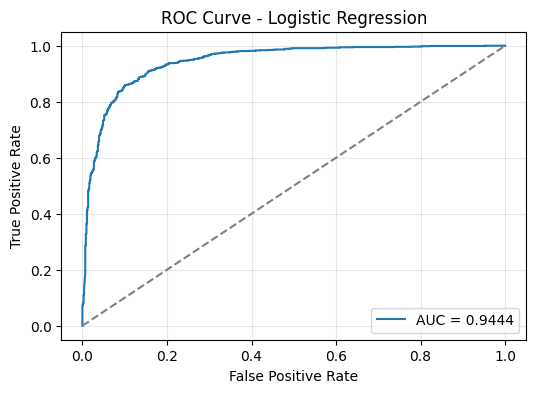


Model training completed successfully!


In [12]:
# ===== Logistic Regression Model =====
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# 1) Train/Test Split  (لو معمول قبل كده، تقدر تتخطاه)
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("Train distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test distribution:", dict(zip(*np.unique(y_test, return_counts=True))))

# -----------------------------------------
# 2) Model Training
# class_weight='balanced' → يعالج الـ imbalance
# -----------------------------------------
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

log_reg.fit(X_train, y_train)

# -----------------------------------------
# 3) Predictions
# -----------------------------------------
y_pred = log_reg.predict(X_test)

# لو الموديل يدعم predict_proba (وهنا يدعم)
y_proba = log_reg.predict_proba(X_test)[:, 1]

# -----------------------------------------
# 4) Evaluation
# -----------------------------------------
print("\n=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ROC AUC
auc = roc_auc_score(y_test, y_proba)
print("\nROC AUC:", round(auc, 4))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], '--', color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nModel training completed successfully!")


 # SVM (LinearSVC)

Train shape: (7968, 17727) | Test shape: (1993, 17727)
Train distribution: {np.int64(0): np.int64(2949), np.int64(1): np.int64(5019)}
Test distribution: {np.int64(0): np.int64(738), np.int64(1): np.int64(1255)}

=== LinearSVC Classification Report ===
              precision    recall  f1-score   support

           0     0.8688    0.8347    0.8514       738
           1     0.9050    0.9259    0.9153      1255

    accuracy                         0.8921      1993
   macro avg     0.8869    0.8803    0.8834      1993
weighted avg     0.8916    0.8921    0.8917      1993

=== Confusion Matrix ===
[[ 616  122]
 [  93 1162]]

Calibrating SVM to get probabilities (this may take some time)...
Calibrated SVM ROC AUC: 0.9466


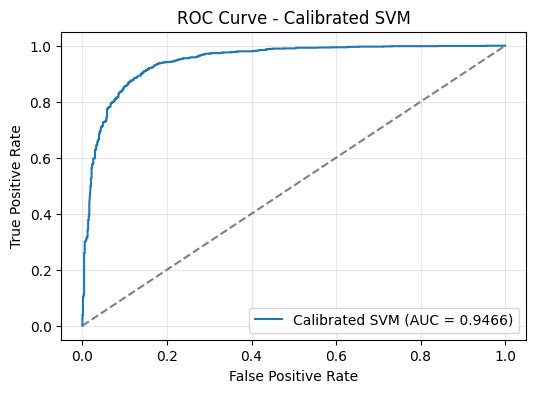


Models saved: linear_svc_model.joblib and linear_svc_calibrated_model.joblib


In [14]:
# ===== Linear SVM (LinearSVC) for text classification =====
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import joblib
import numpy as np

# ---- (افتراض) X_train, X_test, y_train, y_test موجودين بالفعل ----
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test distribution:", dict(zip(*np.unique(y_test, return_counts=True))))

# ---- 1) تدريب LinearSVC ----
svm = LinearSVC(class_weight='balanced', max_iter=10000, random_state=42)
svm.fit(X_train, y_train)

# ---- 2) توقعات وتقييم ----
y_pred_svm = svm.predict(X_test)

print("\n=== LinearSVC Classification Report ===")
print(classification_report(y_test, y_pred_svm, digits=4))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

# ---- 3) (اختياري) الحصول على 'probabilities' عبر Calibration لو محتاج ROC AUC أو thresholding ----
# ملاحظة: LinearSVC لا يدعم predict_proba مباشرة؛ لذا نستخدم CalibratedClassifierCV للحصول على احتمالات.
calibrate_probs = True  # غيّر إلى False لو مش محتاج احتمالات
if calibrate_probs:
    print("\nCalibrating SVM to get probabilities (this may take some time)...")
    svm_cal = CalibratedClassifierCV(svm, method='sigmoid', cv=3)  # أو method='isotonic' لكن يحتاج بيانات أكثر
    svm_cal.fit(X_train, y_train)
    y_proba_svm = svm_cal.predict_proba(X_test)[:, 1]
    try:
        auc = roc_auc_score(y_test, y_proba_svm)
        print("Calibrated SVM ROC AUC:", round(auc,4))
        # رسم ROC
        fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f'Calibrated SVM (AUC = {auc:.4f})')
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - Calibrated SVM')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    except Exception as e:
        print("Could not compute ROC AUC:", e)
else:
    print("\nSkipped probability calibration. If you need probabilities set calibrate_probs=True.")

# ---- 4) حفظ النموذج (الـ svm الرئيسي ونسخة calibrated إن وُجدت) ----
joblib.dump(svm, "linear_svc_model.joblib")
if calibrate_probs:
    joblib.dump(svm_cal, "linear_svc_calibrated_model.joblib")
print("\nModels saved: linear_svc_model.joblib", ("and linear_svc_calibrated_model.joblib" if calibrate_probs else ""))
